In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

##  Setup

In [2]:
DATA_DIR  = r"C:\Users\ASUS G 16\Desktop\fish classify"
PLOTS_DIR = os.path.join(DATA_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Load metrics saved by notebooks 02 and 03
with open(os.path.join(DATA_DIR, "yolo_metrics.json")) as f:
    yolo = json.load(f)
with open(os.path.join(DATA_DIR, "mobilenet_metrics.json")) as f:
    mobilenet = json.load(f)

print("✅ Metrics loaded successfully")
print(f"  YOLOv8      : {yolo}")
print(f"  MobileNetV2 : {mobilenet}")

✅ Metrics loaded successfully
  YOLOv8      : {'Accuracy': 98.47, 'Precision': 98.5, 'Recall': 98.47, 'F1-Score': 98.46}
  MobileNetV2 : {'Accuracy': 90.23, 'Precision': 90.97, 'Recall': 90.23, 'F1-Score': 90.26}


## 1️⃣ Comparison Table

In [3]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

print("=" * 65)
print("     FINAL COMPARISON — 2 MODELS (Test Set)")
print("=" * 65)
print(f"{'Model':<18} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)
print(f"{'MobileNetV2':<18} "
      f"{mobilenet['Accuracy']:>9.2f}% "
      f"{mobilenet['Precision']:>9.2f}% "
      f"{mobilenet['Recall']:>7.2f}% "
      f"{mobilenet['F1-Score']:>7.2f}%")
print(f"{'YOLOv8':<18} "
      f"{yolo['Accuracy']:>9.2f}% "
      f"{yolo['Precision']:>9.2f}% "
      f"{yolo['Recall']:>7.2f}% "
      f"{yolo['F1-Score']:>7.2f}%")
print("-" * 65)

for metric in metrics:
    winner = "MobileNetV2" if mobilenet[metric] >= yolo[metric] else "YOLOv8"
    print(f"  Best {metric:<12}: {winner}")
print("=" * 65)

mob_avg  = np.mean([mobilenet[m] for m in metrics])
yolo_avg = np.mean([yolo[m]      for m in metrics])
best     = "MobileNetV2" if mob_avg >= yolo_avg else "YOLOv8"
print(f"\n🏆 Best Overall Model: {best}")

     FINAL COMPARISON — 2 MODELS (Test Set)
Model                Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
MobileNetV2            90.23%     90.97%   90.23%   90.26%
YOLOv8                 98.47%     98.50%   98.47%   98.46%
-----------------------------------------------------------------
  Best Accuracy    : YOLOv8
  Best Precision   : YOLOv8
  Best Recall      : YOLOv8
  Best F1-Score    : YOLOv8

🏆 Best Overall Model: YOLOv8


## 2️⃣ Comparison Bar Chart

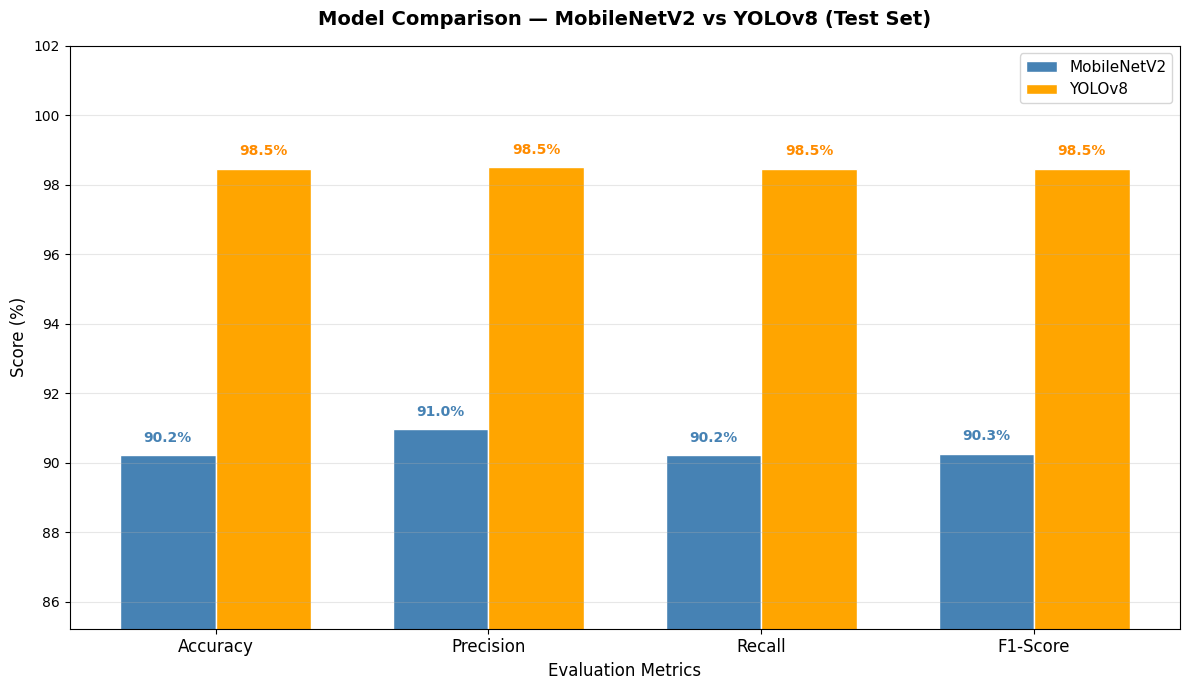

✅ Comparison chart saved


In [4]:
x         = np.arange(len(metrics))
width     = 0.35
mob_vals  = [mobilenet[m] for m in metrics]
yolo_vals = [yolo[m]      for m in metrics]

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, mob_vals,  width, label="MobileNetV2",
               color="steelblue", edgecolor="white")
bars2 = ax.bar(x + width/2, yolo_vals, width, label="YOLOv8",
               color="orange",    edgecolor="white")

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="steelblue")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold", color="darkorange")

ax.set_title("Model Comparison — MobileNetV2 vs YOLOv8 (Test Set)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_xlabel("Evaluation Metrics", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(min(min(mob_vals), min(yolo_vals)) - 5, 102)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Comparison chart saved")

## 3️⃣ Conclusion

In [ ]:
print("=" * 60)
print("                  CONCLUSION")
print("=" * 60)
print()
print("  Both models trained on 31 fish species using the same")
print("  dataset with offline augmentation applied to weak classes,")
print("  image size 224×224, batch size 16, and 30 epochs.")
print()
print("  MobileNetV2 Results (Test Set):")
for k, v in mobilenet.items():
    print(f"    {k:<12}: {v:.2f}%")
print()
print("  YOLOv8 Results (Test Set):")
for k, v in yolo.items():
    print(f"    {k:<12}: {v:.2f}%")
print()
print(f"  🏆 Best Model: {best}")
print(f"     → Selected for the final demo and deployment.")
print(f"     → Achieved higher scores across all 4 metrics.")
print()
print("  Both models demonstrate that deep learning and computer")
print("  vision can support fast and accurate fish species recognition,")
print("  aligned with SDG 14: Life Below Water.")
print("=" * 60)